# Download statistics for machine-learning libraries from Anaconda

This notebook aggregates some package download stats accross anaconda sources.
pypi sources can be inspected online, eg on [clickpy](https://clickpy.clickhouse.com/dashboard/scikit-learn)
Note that some packages (eg tensorflow) explicitely recommend to use pip rather than conda

Upstream [README](https://github.com/ContinuumIO/anaconda-package-data/blob/master/README.md#quickstart).

The following packages are useful to install to run it: intake, dask, requests, aiohttp, pyarrow, intake-parquet, s3fs, matplotlib, joblib, ibis-framework[clickhouse]

In [ ]:
# Import necessary libraries
import intake
import dask
import pandas as pd

In [2]:
# Get the data
cat = intake.open_catalog('https://raw.githubusercontent.com/anaconda/anaconda-package-data/master/catalog/anaconda_package_data.yaml')

In [27]:
# required variable assignments
years = range(2023, 2026)
packages = ["scikit-learn", "pytorch", "cuml", "tensorflow", "py-xgboost", "lightgbm", "catboost"]

#data_source = "anaconda"

In [4]:
# Initialize the dataframe to store the results
downloads_conda = pd.DataFrame({
    "pkg_name": [],
    "year": [],
    "downloads": [
    ]
})

# Download the data for each year and package, and aggregate per year
for year in years:
    print(year)
    df_year_monthly_res = cat.anaconda_package_data_by_year_month_res(year=year).to_dask().compute()
    for pkg_name in packages:
        pkg_year = df_year_monthly_res[
                (df_year_monthly_res["pkg_name"] == pkg_name)
                #& (df_year_monthly_res["data_source"] == data_source)   
            ].reset_index(drop=True)['counts'].sum()
        downloads_conda = pd.concat([downloads_conda, pd.DataFrame({
            "pkg_name": [pkg_name],
            "year": [year],
            "downloads": [pkg_year]
        })], ignore_index=True)

2023
2024
2025


In [5]:
downloads_conda['year'] = downloads_conda['year'].astype(int)
downloads_conda['downloads'] = downloads_conda['downloads'].astype(int)
downloads_conda.to_csv("anaconda_downloads.csv", index=False)
downloads_conda

,pkg_name,year,downloads
0,scikit-learn,2023,15485322
1,pytorch,2023,11001560
2,cuml,2023,171191
3,tensorflow,2023,2432514
4,py-xgboost,2023,2585041
5,lightgbm,2023,1022345
6,catboost,2023,325039
7,scikit-learn,2024,19750039
8,pytorch,2024,11969746
9,cuml,2024,336401


In [31]:
 # Pivot the dataframe to have years as columns and package names as index
pivot_conda = downloads_conda.pivot(index='pkg_name', columns='year', values='downloads')
pivot_conda

year,2023,2024,2025
pkg_name,,,
catboost,325039,369808,463451
cuml,171191,336401,145292
lightgbm,1022345,1431388,2636069
py-xgboost,2585041,4795679,5129384
pytorch,11001560,11969746,11595039
scikit-learn,15485322,19750039,23826374
tensorflow,2432514,1793509,1745782


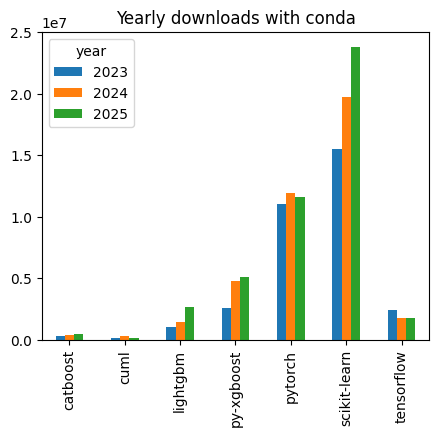

In [32]:
# Use the pivoted dataframe to create a bar plot
pivot_conda.plot(kind='bar', figsize=(5, 4), title='Yearly downloads with conda')
from matplotlib import pyplot as plt
plt.xlabel("");

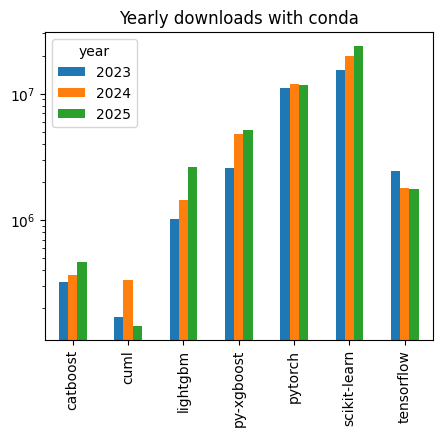

In [33]:
# Same but in log scale, to facilate the comparison of the packages with lower download counts
pivot_conda.plot(kind='bar', figsize=(5, 4), title='Yearly downloads with conda')
ax = plt.gca()
ax.set_yscale('log')
plt.xlabel("");

In [9]:
# Let's check which channels we have covered
list(df_year_monthly_res['data_source'].unique())

['conda-forge',
 'rapidsai-nightly',
 'bioconda',
 'nvidia',
 'anaconda',
 'rapidsai',
 'pytorch',
 'pyviz',
 'pytorch-test',
 'plotly',
 'rdkit']

# Now with pypi statistics

To get data across multiple years, I query pepy.tech

In [35]:
import clickhouse_connect

CLICKHOUSE_HOST = "sql-clickhouse.clickhouse.com"
CLICKHOUSE_USER = "demo"      # public read-only user
CLICKHOUSE_PORT = 443         # HTTPS


def get_yearly_downloads(packages):
    start_year = 2023

    client = clickhouse_connect.get_client(
        host=CLICKHOUSE_HOST,
        port=CLICKHOUSE_PORT,
        username=CLICKHOUSE_USER,
        secure=True
    )

    package_list = ", ".join(f"'{p}'" for p in packages)

    query = f"""
        SELECT
            project,
            toYear(date) AS year,
            sum(count) AS downloads
        FROM pypi.pypi_downloads_per_day
        WHERE project IN ({package_list})
          AND toYear(date) >= {start_year}
        GROUP BY project, year
        ORDER BY project, year
    """

    result = client.query(query)

    # Convert to list of dicts
    columns = result.column_names
    rows = [dict(zip(columns, row)) for row in result.result_rows]

    return rows

In [59]:
# pytorch is called torch in PyPI, so we need to adjust the package names accordingly
packages_pypi = packages.copy()
packages_pypi[packages_pypi.index("pytorch")] = "torch"
# likewise, cuML is called cuml in PyPI
packages_pypi[packages_pypi.index("cuml")] = "cuml"
# and py-xgboost is called xgboost in PyPI
packages_pypi[packages_pypi.index("py-xgboost")] = "xgboost"

stats = get_yearly_downloads(packages_pypi)

In [60]:
# Turn to a dataframe for easier manipulation
downloads_pypi = pd.DataFrame(stats)
# rename columns for consistency with conda data
downloads_pypi.rename(columns={"project": "pkg_name"}, inplace=True)
downloads_pypi = downloads_pypi.query("year < 2026")
# rename torch back to pytorch for consistency with conda data
downloads_pypi.loc[downloads_pypi['pkg_name'] == 'torch', 'pkg_name'] = 'pytorch'
# rename cuml back to cuML for consistency with conda data
downloads_pypi.loc[downloads_pypi['pkg_name'] == 'cuml', 'pkg_name'] = 'cuml'
# rename xgboost back to py-xgboost for consistency with conda data
downloads_pypi.loc[downloads_pypi['pkg_name'] == 'xgboost', 'pkg_name'] = 'py-xgboost'
downloads_pypi.to_csv("pypi_downloads.csv", index=False)
downloads_pypi

,pkg_name,year,downloads
0,catboost,2023,27121259
1,catboost,2024,31313015
2,catboost,2025,45035151
4,cuml,2023,22181
5,cuml,2024,37229
6,cuml,2025,40425
8,lightgbm,2023,77404905
9,lightgbm,2024,107774752
10,lightgbm,2025,128359114
12,scikit-learn,2023,480011649


In [61]:
pivot_pypi = downloads_pypi.pivot(index='pkg_name', columns='year', values='downloads')
pivot_pypi

year,2023,2024,2025
pkg_name,,,
catboost,27121259,31313015,45035151
cuml,22181,37229,40425
lightgbm,77404905,107774752,128359114
py-xgboost,119483322,254514996,351767023
pytorch,140857666,360688186,684135960
scikit-learn,480011649,851727956,1428034392
tensorflow,200463503,247139552,284185267


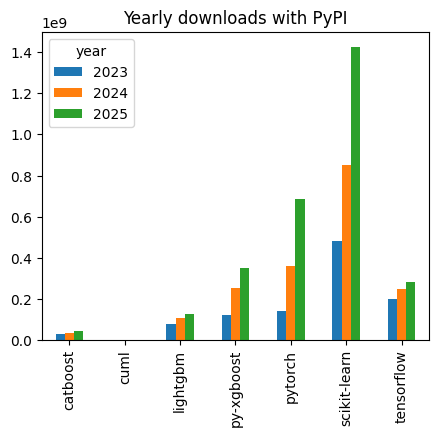

In [62]:
# Use the pivoted dataframe to create a bar plot
pivot_pypi.plot(kind='bar', figsize=(5, 4), title='Yearly downloads with PyPI')
from matplotlib import pyplot as plt
plt.xlabel("");

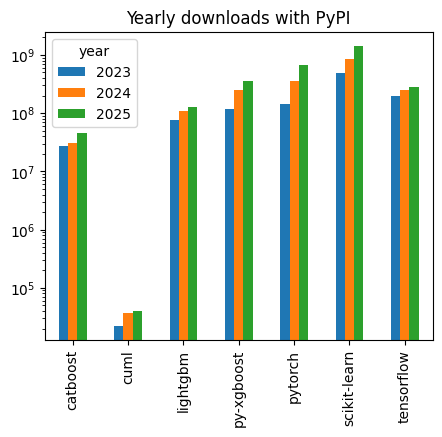

In [64]:
# Same but in log scale, to facilate the comparison of the packages with lower download counts
pivot_pypi.plot(kind='bar', figsize=(5, 4), title='Yearly downloads with PyPI')
ax = plt.gca()
ax.set_yscale('log')
plt.xlabel("");

# Combining conda and PyPI data

In [65]:
total_downloads = pivot_pypi + pivot_conda
total_downloads

year,2023,2024,2025
pkg_name,,,
catboost,27446298,31682823,45498602
cuml,193372,373630,185717
lightgbm,78427250,109206140,130995183
py-xgboost,122068363,259310675,356896407
pytorch,151859226,372657932,695730999
scikit-learn,495496971,871477995,1451860766
tensorflow,202896017,248933061,285931049


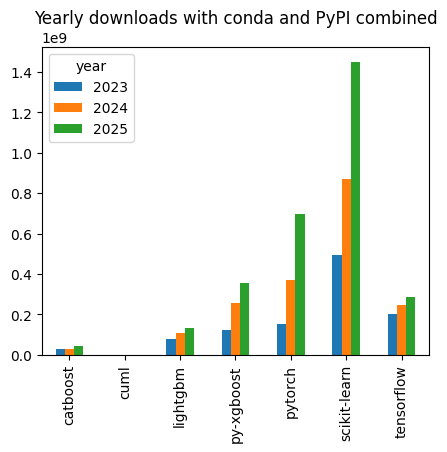

In [66]:
total_downloads.plot(kind='bar', figsize=(5, 4), title='Yearly downloads with conda and PyPI combined')
ax = plt.gca()
plt.xlabel("");

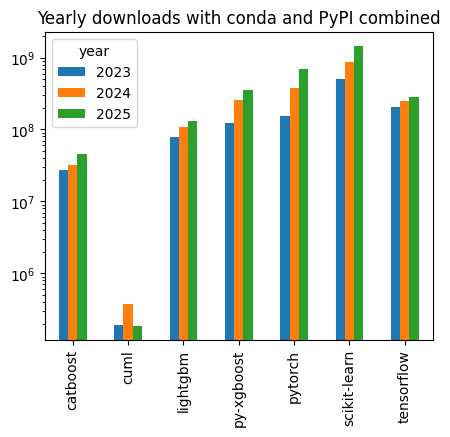

In [67]:
total_downloads.plot(kind='bar', figsize=(5, 4), title='Yearly downloads with conda and PyPI combined')
ax = plt.gca()
ax.set_yscale('log')
plt.xlabel("");